In [29]:
import copy
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

In [30]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using Device:", device)

Using Device: mps


In [31]:
labels = pd.read_csv("../data/processed/galaxy_labels.csv")

labels.head()

,GalaxyID,Galaxy_Class
0,100008,Spiral
1,100023,Barred Spiral
2,100053,Oval
3,100078,Elliptical
4,100090,Elliptical


In [32]:
encoder = LabelEncoder()

labels["Label"] = encoder.fit_transform(labels["Galaxy_Class"])

NUM_CLASSES = len(encoder.classes_)

print("Classes:", encoder.classes_)
print("Number of Classes:", NUM_CLASSES)

Classes: ['Barred Spiral' 'Cigar' 'Disk' 'Edge-on Spiral' 'Elliptical' 'Irregular'
 'Merger' 'Other' 'Oval' 'Ring Galaxy' 'Spiral']
Number of Classes: 11


In [33]:
train_df, val_df = train_test_split(
    labels,
    test_size=0.20,
    stratify=labels["Label"],
    random_state=42
)

print(len(train_df), len(val_df))

49262 12316


In [34]:
IMAGE_DIR = Path("../data/raw/images_training_rev1")

In [35]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [36]:
class GalaxyDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(
            self.image_dir / f"{row['GalaxyID']}.jpg"
        ).convert("RGB")

        label = row["Label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [37]:
train_dataset = GalaxyDataset(
    train_df,
    IMAGE_DIR,
    train_transform
)

val_dataset = GalaxyDataset(
    val_df,
    IMAGE_DIR,
    val_transform
)

In [38]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 1540
Validation batches: 385


In [39]:
model = models.resnet18(
    weights=ResNet18_Weights.DEFAULT
)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=11, bias=True)


In [26]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [40]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

In [41]:
EPOCHS = 5

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_acc = 0.0

In [42]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        correct += predicted.eq(labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [43]:
def validate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [45]:
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

In [46]:
for epoch in range(EPOCHS):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_accuracy": val_acc,
                "classes": encoder.classes_
            },
            "../models/best_resnet18_checkpoint.pth"
        )

    elapsed = time.time() - start

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

Epoch 1/5 | Train Loss: 1.7492 | Train Acc: 0.3910 | Val Loss: 1.6964 | Val Acc: 0.3987 | Time: 566.9s
Epoch 2/5 | Train Loss: 1.6963 | Train Acc: 0.4058 | Val Loss: 1.6748 | Val Acc: 0.4163 | Time: 414.5s
Epoch 3/5 | Train Loss: 1.6820 | Train Acc: 0.4100 | Val Loss: 1.6926 | Val Acc: 0.4056 | Time: 485.2s
Epoch 4/5 | Train Loss: 1.6788 | Train Acc: 0.4113 | Val Loss: 1.6734 | Val Acc: 0.4210 | Time: 2404.3s
Epoch 5/5 | Train Loss: 1.6712 | Train Acc: 0.4128 | Val Loss: 1.7097 | Val Acc: 0.3997 | Time: 16094.6s


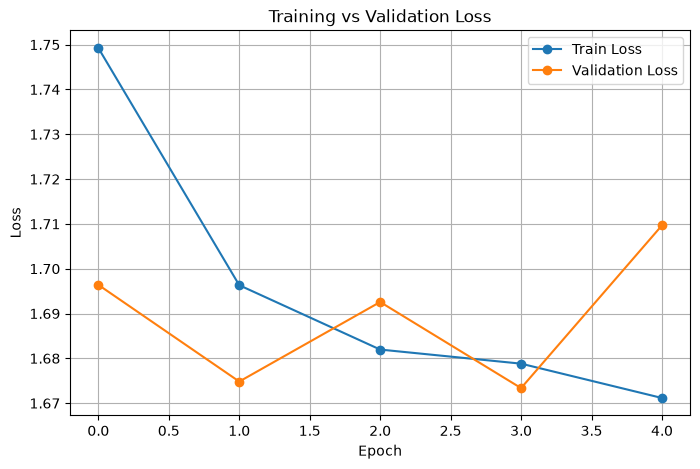

In [47]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.grid(True)

plt.legend()

plt.show()

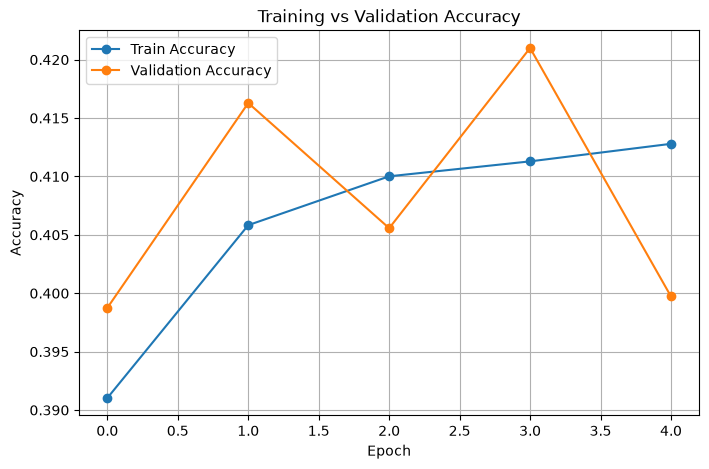

In [48]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, marker="o", label="Train Accuracy")
plt.plot(val_accs, marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.grid(True)

plt.legend()

plt.show()

In [49]:
print("=" * 50)
print("Training Completed")
print("=" * 50)

print(f"Best Validation Accuracy : {best_acc:.4f}")

print(f"Final Training Accuracy  : {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")

Training Completed
Best Validation Accuracy : 0.4210
Final Training Accuracy  : 0.4128
Final Validation Accuracy: 0.3997
